<a href="https://colab.research.google.com/github/artreas/DATA_SCEINCE_ASSIGNMENT/blob/main/Global_Terrorism_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Global Terrorism Data.csv", encoding='latin1')
df.head()

/tmp/ipykernel_4612/3002089456.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Global Terrorism Data.csv", encoding='latin1')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [3]:
df = df[['iyear','imonth','country_txt','region_txt','city',
         'attacktype1_txt','targtype1_txt','weaptype1_txt',
         'nkill','nwound']]

df = df.fillna(0)

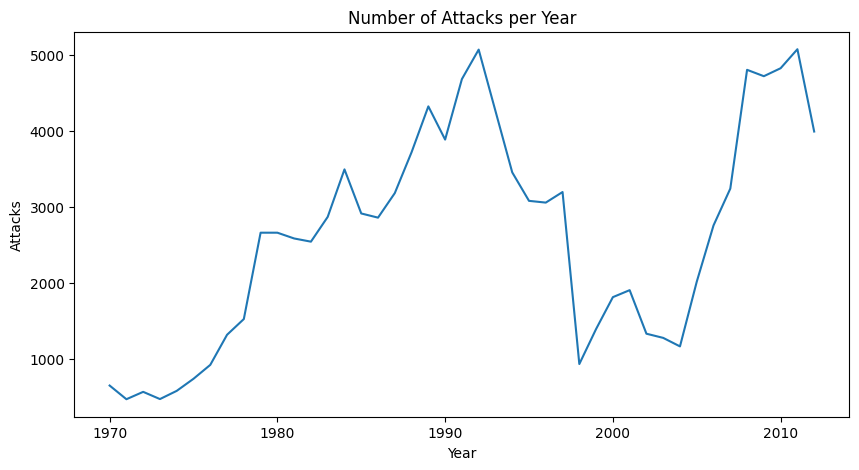

In [4]:
year_counts = df['iyear'].value_counts().sort_index()

plt.figure(figsize=(10,5))
year_counts.plot(kind='line')
plt.title("Number of Attacks per Year")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

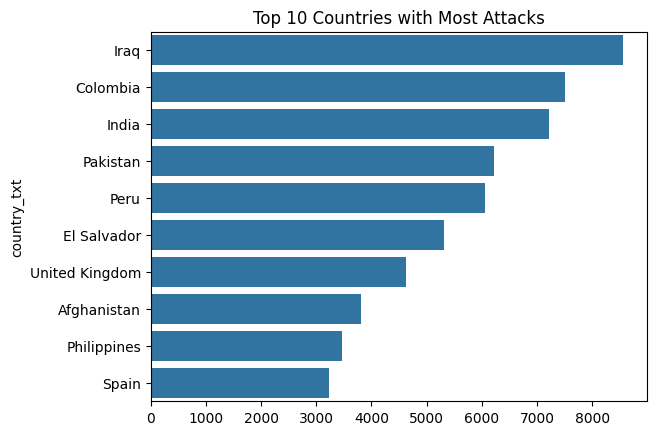

In [5]:
top_countries = df['country_txt'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries with Most Attacks")
plt.show()

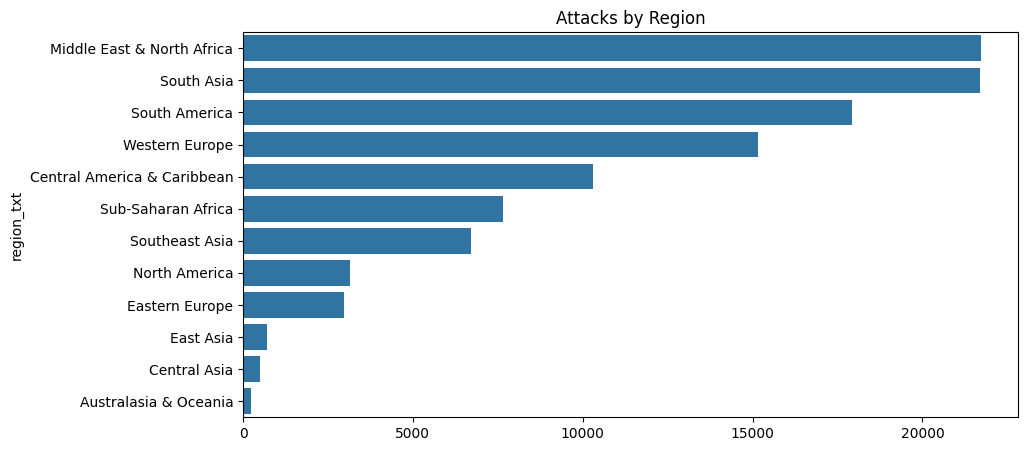

In [6]:
region_counts = df['region_txt'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title("Attacks by Region")
plt.show()

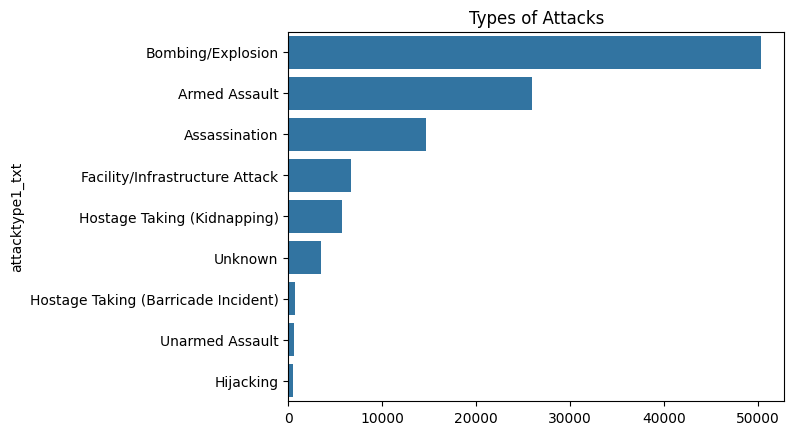

In [7]:
attack_types = df['attacktype1_txt'].value_counts()

sns.barplot(x=attack_types.values, y=attack_types.index)
plt.title("Types of Attacks")
plt.show()

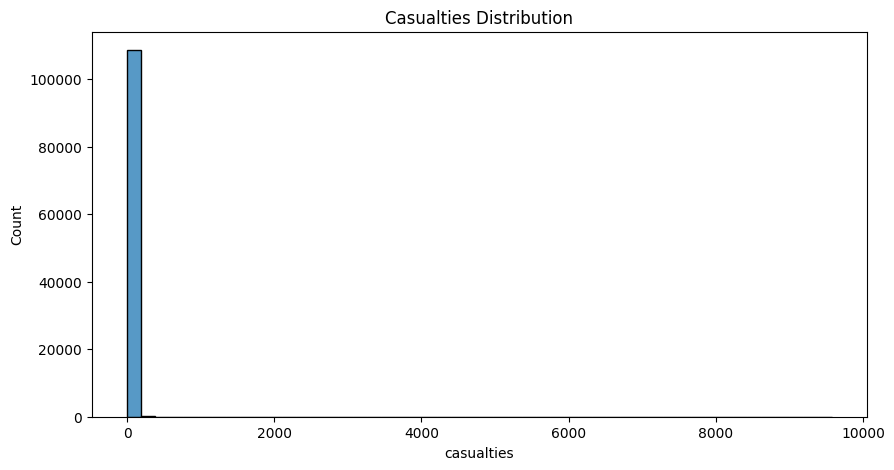

In [8]:
df['casualties'] = df['nkill'] + df['nwound']

plt.figure(figsize=(10,5))
sns.histplot(df['casualties'], bins=50)
plt.title("Casualties Distribution")
plt.show()

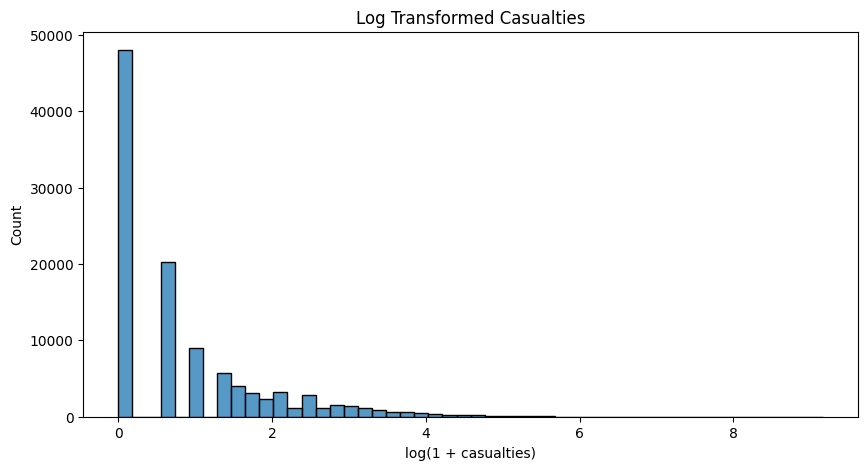

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['casualties']), bins=50)
plt.title("Log Transformed Casualties")
plt.xlabel("log(1 + casualties)")
plt.show()

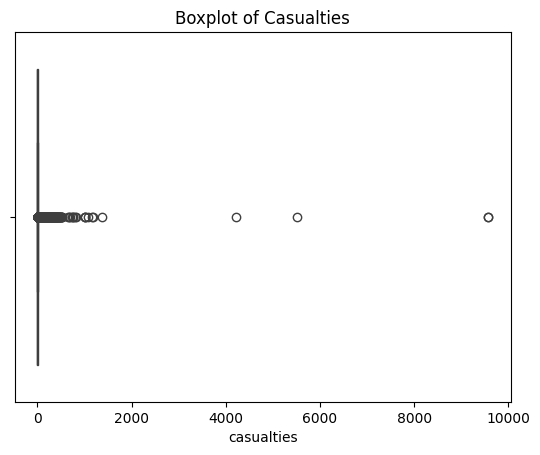

In [10]:
sns.boxplot(x=df['casualties'])
plt.title("Boxplot of Casualties")
plt.show()

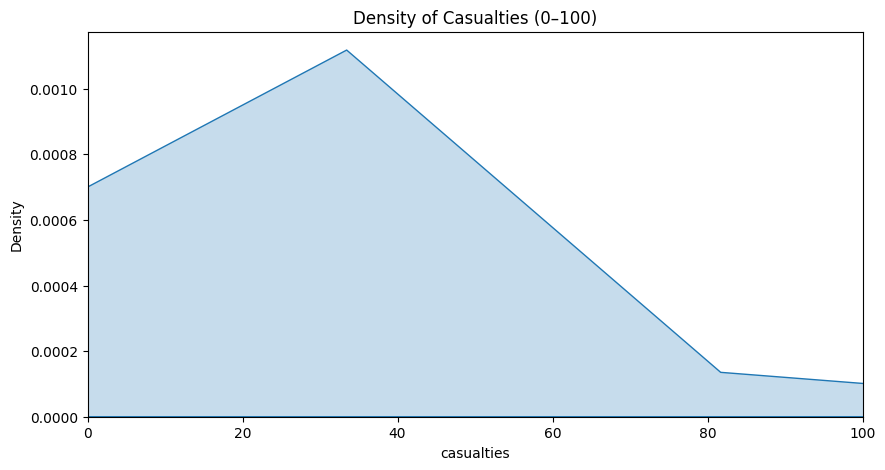

In [11]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['casualties'], fill=True)
plt.xlim(0,100)
plt.title("Density of Casualties (0–100)")
plt.show()

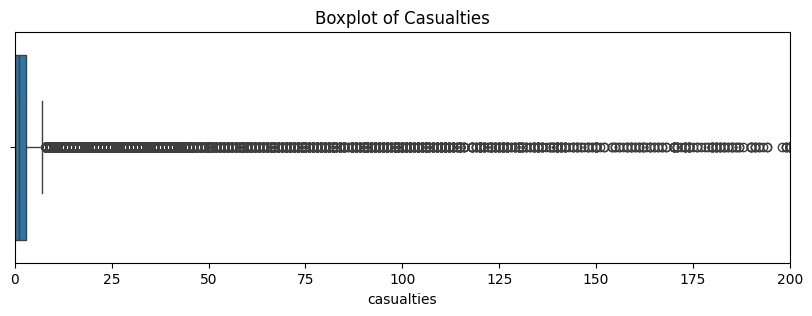

In [12]:
plt.figure(figsize=(10,3))
sns.boxplot(x=df['casualties'])
plt.xlim(0,200)
plt.title("Boxplot of Casualties")
plt.show()

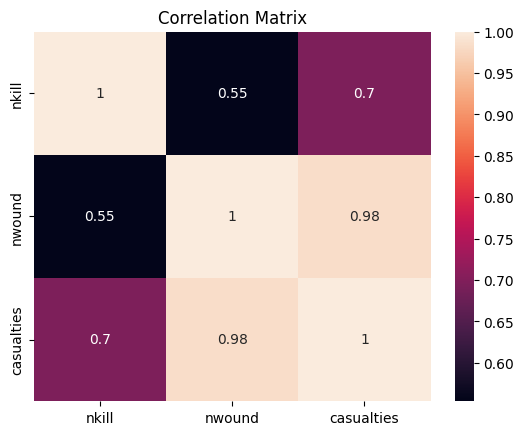

In [13]:
sns.heatmap(df[['nkill','nwound','casualties']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

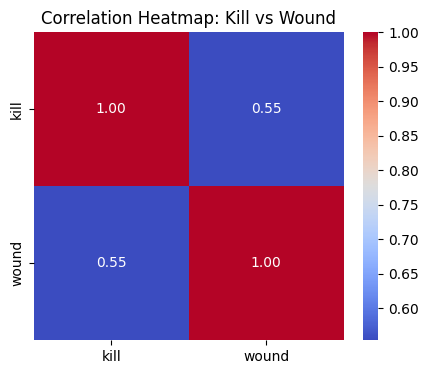

In [14]:
df.rename(columns={
    'nkill': 'kill',
    'nwound': 'wound'
}, inplace=True)
corr = df[['kill', 'wound']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Kill vs Wound")
plt.show()